This code is created to run assimilations with all UMRB stations and then without all UMRB stations. A difference map is then made to compare the differences between the two.

In [1]:
import sys
import os as os

import geopandas as gpd
import numpy as np
from numpy.polynomial import Polynomial
import psycopg2
from netCDF4 import Dataset

from tqdm import tqdm
from multiprocessing import Pool
import statsmodels.api as sm
from scipy import stats
# from scipy import optimize

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature as cfNEF

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
#import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

import rasterio
import xarray as xr

import random
import subprocess
import netCDF4
import shutil

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
import seaborn as sns
from scipy.stats import gaussian_kde

import pathlib
import glob
import pandas as pd

from sklearn.metrics import r2_score

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# Assimilation Code (Run assimilation with and without UMRB Stations)

Create a list of all the UMRB station_id's

In [2]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

Run assimilation with all UMRB Stations included if Carrie has not aready run one for the date (Baseline)

In [2]:
# Inputs for code:
folder_name = "12_28_23_UMRB_Region_Assimilation"
start_date = "2023122712" # These are the numbers within the shapefile like shown in shapefile name above
end_date = "2023122812" # These are the numbers within the shapefile like shown in shapefile name above


# Enter command you want to run (Look at commands in Greg's Examples, this command uses assigned IDW creteria to create new nudging layer)
# Also make sure IDW parameters are correct 
cmd = f"python ./snodas_idw.py -k -i 3 50 2 2 200 {start_date} {end_date} central -f ../Test_Runs/{folder_name}" #Careful with the US, West, etc. part in command

# Run Greg's code using the above inputs and chosen command in cmd line
subprocess.run(cmd, capture_output=True)

CompletedProcess(args='python ./snodas_idw.py -k -i 3 50 2 2 200 2023122712 2023122812 central -f ../Test_Runs/12_28_23_UMRB_Region_Assimilation', returncode=1, stdout=b'', stderr=b'2024-07-24 15:13:17 Mountain Daylight Time RTI-106712 snodas_idw.py[19720-MainThread]: WARNING: No [-b, --no_database] argument provided, but assumed because this system appears to be non-operational.\r\n2024-07-24 15:13:17 Mountain Daylight Time RTI-106712 snodas_idw.py[19720-MainThread]: WARNING: Unable to create output directory ../Test_Runs/12_28_23_UMRB_Region_Assimilation. Will use c:\\Repos\\umrb-snodas\\src\r\n2024-07-24 15:13:17 Mountain Daylight Time RTI-106712 snodas_idw.py[19720-MainThread]: INFO: Input shapefile path is ../Test_Runs/12_28_23_UMRB_Region_Assimilation\\ssm1054_md_based_2023122712_2023122812_central.shp\r\n2024-07-24 15:13:17 Mountain Daylight Time RTI-106712 snodas_idw.py[19720-MainThread]: INFO: Limiting MD_DENSITY and recalculating deltas for 4 simulated (depth-based) SWE obser

Run assimilation without any UMRB stations and create difference map

In [3]:
# Inputs for code:
net_CDF1_Path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_base_updated\ssm1054_2023122812.nc" # This file is the one comparison file (so use baseline netcdf output here)
net_CDF2_Path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated\ssm_process_region_2023122712_2023122812_swe_central.nc" # This is the file that creates the boundaries for the assimilation.
net_CDF_name_us = "ssm_process_region_2023122712_2023122812_swe_central.nc"
net_CDF_name = "ssm1054_2023122812.nc" # When changing to baseline output netCDF you still need to save with the name of original example run name!!
shapefile_name = "ssm1054_md_based_2023122712_2023122812_central.shp"

# Inputs for code:
folder_name = "snodas_assim_20231228_with_umrb_updated"
start_date = "2023122712" # These are the numbers within the shapefile like shown in shapefile name above
end_date = "2023122812" # These are the numbers within the shapefile like shown in shapefile name above

# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{shapefile_name}"
gdf = gpd.read_file(shapefile_path)

# Create new shapefile with no UMRB stations in it:
# Remove all rows where 'STATION_ID' is in UMRB_ID
gdf_2 = gdf[~gdf['STATION_ID'].isin(UMRB_ID)]

# Change folder and shapefile names for new assimilation (Need to change these as well!!!!)
folder_name = f"snodas_assim_20231228_NO_UMRB_updated"
shapefile_name = f"ssm1054_md_based_2023122712_2023122812_central0.shp" # Change shapefile name
net_CDF_name_us = f"ssm_process_region_2023122712_2023122812_swe_central0.nc" # Change processing region netCDF name

# Write new shapefile to new folder - had to save twice to get correct shapefile name - Ideas???
gdf_2.to_file(f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}")
gdf_2.to_file(f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{shapefile_name}")

# Copy netCDF's from orgignal folder to new folder (Need original netCDF's to run)
shutil.copy(net_CDF1_Path,f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{net_CDF_name}" )
shutil.copy(net_CDF2_Path,f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{net_CDF_name_us}" )

# Enter command you want to run (Look at commands in Greg's Examples, this command uses assigned IDW creteria to create new nudging layer) 
cmd = f"python ./snodas_idw.py -k -i 3 50 2 2 200 {start_date} {end_date} central0 -f ../Test_Runs/{folder_name}" #Careful with the US, West, etc. part in command
    
# Run Greg's code using the above inputs and chosen command in cmd line
subprocess.run(cmd, capture_output=True)

CompletedProcess(args='python ./snodas_idw.py -k -i 3 50 2 2 200 2023122712 2023122812 central0 -f ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated', returncode=0, stdout=b'', stderr=b'2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: WARNING: No [-b, --no_database] argument provided, but assumed because this system appears to be non-operational.\r\n2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: WARNING: Unable to create output directory ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated. Will use c:\\Repos\\umrb-snodas\\src\r\n2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: INFO: Input shapefile path is ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated\\ssm1054_md_based_2023122712_2023122812_central0.shp\r\n2024-07-16 09:08:11 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: INFO: Limiting MD_DENSITY and recalculating deltas for 32 simulated (depth-based

# Create Difference Maps of runs with UMRB stations and without UMRB Stations

## 12/28/23 Assimilation

### Create a Nudging Field using all stations (With UMRB Stations)

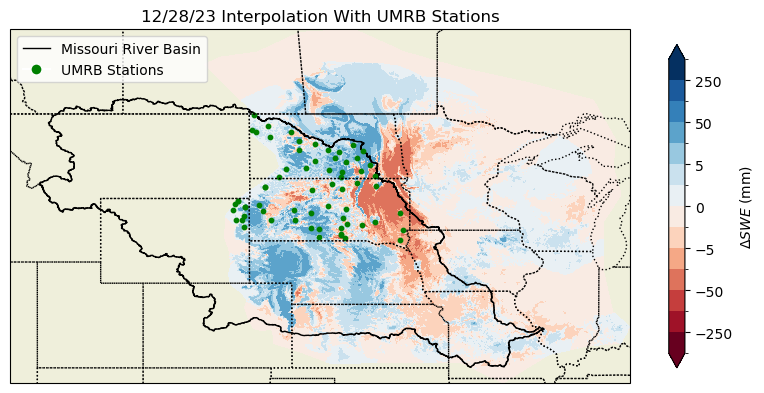

In [4]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated_base\ssm1054_snodas_idw_test_2023122812_central.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label=r'$\Delta SWE$ (mm)',shrink=0.7)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper left')

plt.title('12/28/23 Interpolation With UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Creates a Nudging Field Like above but not using UMRB Stations (Without UMRB Stations = new_variable_data)

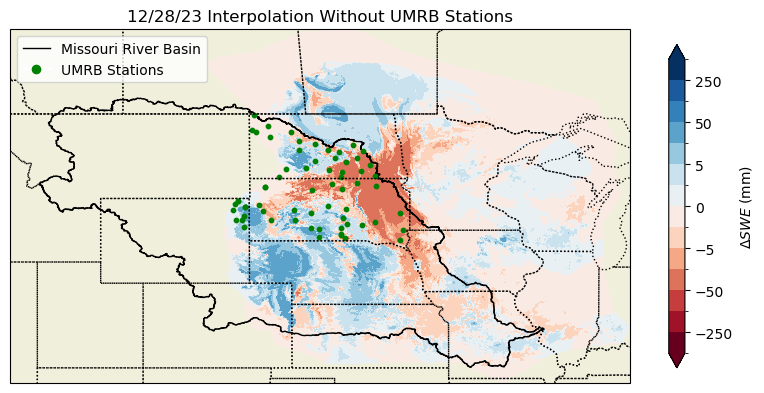

In [5]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_NO_UMRB_updated\ssm1054_snodas_idw_test_2023122812_central0.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000
new_variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, new_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label=r'$\Delta SWE$ (mm)',shrink=0.7)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper left')

plt.title('12/28/23 Interpolation Without UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Create difference data and difference map comparing with and without UMRB

In [6]:
difference_variable_data = (variable_data - new_variable_data)

difference_variable_data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-99999.0)

### Create a Difference Map of With and Without UMRB Stations (difference_variable_data)

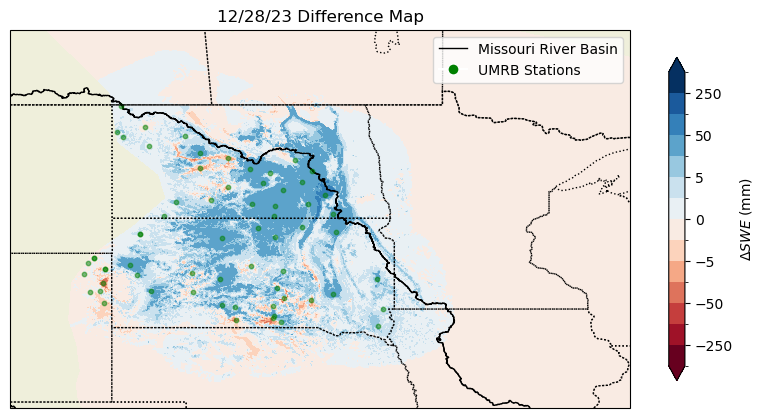

In [7]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated_base\ssm1054_snodas_idw_test_2023122812_central.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, difference_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label=r'$\Delta SWE$ (mm)',shrink=0.7)
plt.title('12/28/23 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5,transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed
latitude_padding_2 = (maxx - minx) * 0.3  # Adjust padding percentage as needed
latitude_padding_3 = (maxy - miny) * 0.1  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding_3
new_minx = minx + latitude_padding_2
ax.set_extent([new_minx, maxx, new_miny, new_maxy], crs=ccrs.PlateCarree())

plt.legend(handles=custom_legend, loc='upper right')

plt.grid(True)
plt.show()

### Create difference map and mask delata SWE values from -1 to 1 for cleaner look and to follow how NOAA employees did it!!!!!!

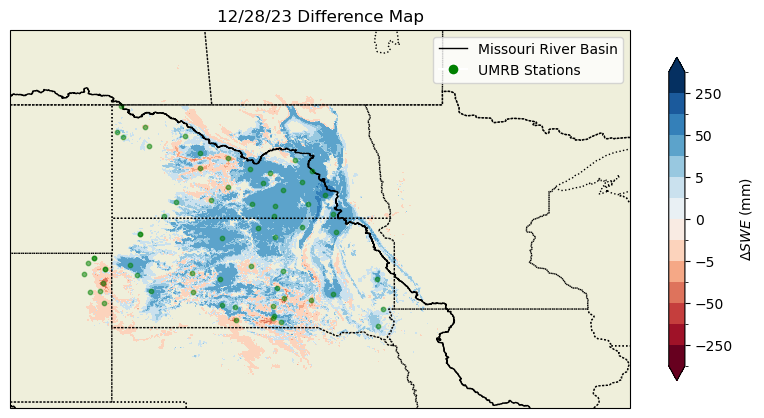

In [9]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated_base\ssm1054_snodas_idw_test_2023122812_central.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# First, mask -9999 values
masked_data = np.ma.masked_where(difference_variable_data == -9999, difference_variable_data)

# Then, mask any values between -1 and 1
masked_data = np.ma.masked_inside(masked_data, -1, 1)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data with both -9999 and values between -1 and 1 masked
contour = ax.contourf(lons, lats, masked_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)', shrink=0.7)
plt.title('12/28/23 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed
latitude_padding_2 = (maxx - minx) * 0.3  # Adjust padding percentage as needed
latitude_padding_3 = (maxy - miny) * 0.1  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding_3
new_minx = minx + latitude_padding_2
ax.set_extent([new_minx, maxx, new_miny, new_maxy], crs=ccrs.PlateCarree())

plt.legend(handles=custom_legend, loc='upper right')

plt.grid(True)
plt.show()





### Looking at descriptive statistics of both Nudging Layers (With and Without UMRB Stations) and the statistics for the Difference Map (With UMRB - Without UMRB)

These are stats for With UMRB Stations Nudging Layer

In [76]:
# Compute basic statistics for netCDF files 
data_min = np.min(variable_data)
data_max = np.max(variable_data)
data_mean = np.mean(variable_data)
data_std = np.std(variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)


Minimum value: -37.917669862508774
Maximum value: 36.41462326049805
Mean value: -0.7353154617091539
Standard deviation: 5.170142405442958


These are stats for Without UMRB Nudging Layer

In [77]:
# Compute basic statistics for netCDF files 
data_min = np.min(new_variable_data)
data_max = np.max(new_variable_data)
data_mean = np.mean(new_variable_data)
data_std = np.std(new_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -37.917666137218475
Maximum value: 32.362956553697586
Mean value: -1.2395038758053063
Standard deviation: 5.406056231569338


These are stats for the difference between Nudging Layers (With UMRB - Without UMRB)

In [78]:
# Compute basic statistics for netCDF files 
data_min = np.min(difference_variable_data)
data_max = np.max(difference_variable_data)
data_mean = np.mean(difference_variable_data)
data_std = np.std(difference_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -37.29965165257454
Maximum value: 58.42896178364754
Mean value: 0.5041884140961528
Standard deviation: 3.4031403601146475


Look at difference data without the zero values to see how much values deviate from eachother (This current code is using the absolute value of the difference values exluding zeroes to examine magnitude!!!!)

In [79]:
# Remove all zero values from difference data

# Converting the data to NumPy arrays
difference_variable_data = np.array(difference_variable_data)

# Create array without any zero and -99999 values
non_zero_difference_data = np.abs(difference_variable_data[(difference_variable_data != 0) & (difference_variable_data != -99999)])

Histogram of the above none zero absolute value difference values

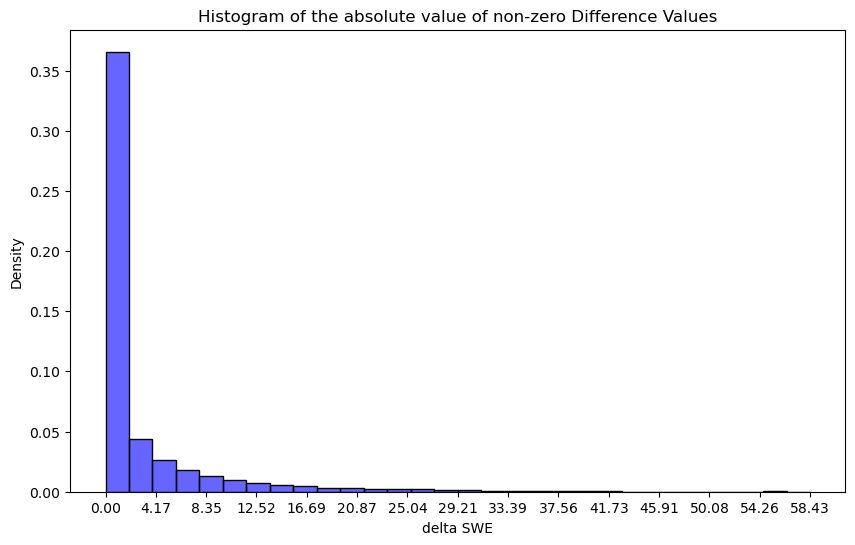

In [80]:
#create histogram and PDF for Without UMRB station assimilation

# Step 4: Flatten the variable_data to 1D array for histogram
flat_data = non_zero_difference_data.flatten()

# Step 5: Plot the histogram and PDF
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(flat_data, bins=30, kde=False, stat='density', color='blue', alpha=0.6)

# Adding labels and title
plt.xlabel('delta SWE')
plt.ylabel('Density')
plt.title('Histogram of the absolute value of non-zero Difference Values')

# Set more tick marks on x-axis
plt.xticks(np.linspace(min(flat_data), max(flat_data), num=15))

# Show the plot
plt.show()

Here are the descriptive statistics for the non zero absolute value of the difference values (Magnitude of difference values)

In [81]:
# Compute basic statistics
data_min = np.min(non_zero_difference_data)
data_max = np.max(non_zero_difference_data)
data_mean = np.mean(non_zero_difference_data)
data_std = np.std(non_zero_difference_data)

# Compute percentiles
percentiles = np.percentile(non_zero_difference_data, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])


Minimum value: 7.945900881711765e-12
Maximum value: 58.42896178364754
Mean value: 2.8706267892557866
Standard deviation: 6.153017772539278
25th percentile: 0.00595908889522434
Median (50th percentile): 0.20856054470641539
75th percentile: 2.7009401746909134


## 12/11/22 Assimilation

### Create a Nudging Field using all stations (With UMRB Stations)

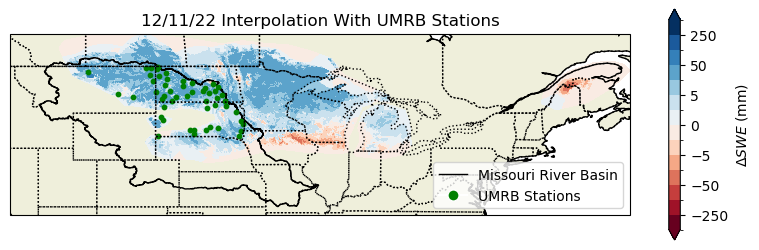

In [18]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_2022121112.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm1054_md_based_2022121012_2022121112_east.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)',shrink=0.5)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='lower right')

plt.title('12/11/22 Interpolation With UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Creates a Nudging Field Like above but not using UMRB Stations (Without UMRB Stations = new_variable_data)

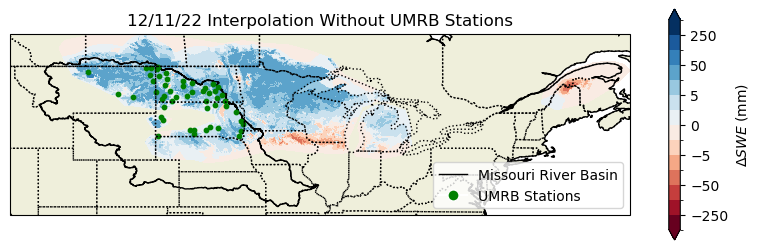

In [19]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_snodas_idw_test_2022121112_east0.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
new_variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm1054_md_based_2022121012_2022121112_east.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, new_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)',shrink=0.5)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='lower right')

plt.title('12/11/22 Interpolation Without UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Create difference data and difference map comparing with and without UMRB

In [20]:
difference_variable_data = (variable_data - new_variable_data)

difference_variable_data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-99999.0)

### Create a Difference Map of With and Without UMRB Stations (difference_variable_data)

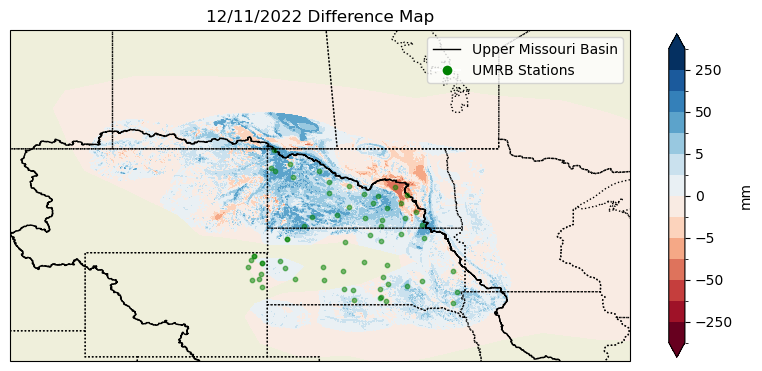

In [16]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_2022121112.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, difference_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='mm',shrink=0.7)
plt.title('12/11/2022 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Upper Missouri Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper right')

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding
ax.set_extent([minx, maxx, new_miny, new_maxy], crs=ccrs.PlateCarree())


plt.grid(True)
plt.show()

### Create difference map and mask delata SWE values from -1 to 1 for cleaner look and to follow how NOAA employees did it!!!!!!

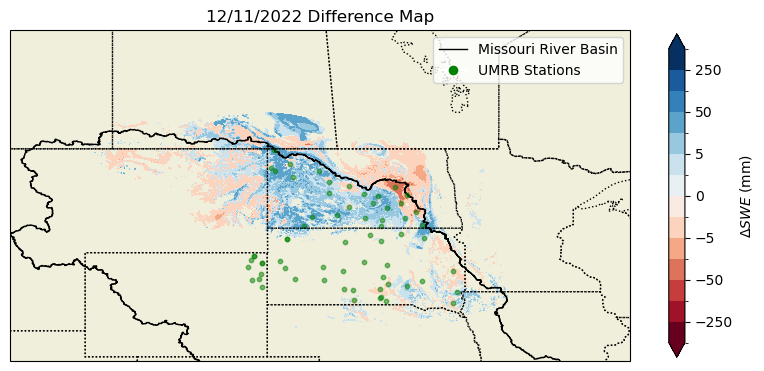

In [22]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_2022121112.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# First, mask -9999 values
masked_data = np.ma.masked_where(difference_variable_data == -9999, difference_variable_data)

# Then, mask any values between -1 and 1
masked_data = np.ma.masked_inside(masked_data, -1, 1)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data with both -9999 and values between -1 and 1 masked
contour = ax.contourf(lons, lats, masked_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)', shrink=0.7)
plt.title('12/11/2022 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper right')

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding
ax.set_extent([minx, maxx, new_miny, new_maxy], crs=ccrs.PlateCarree())

plt.grid(True)
plt.show()






### Looking at descriptive statistics of netCDF files (These are basic statistics for the delta SWE values of With UMRB Run (variable_data) and Without UMRB Run (new_variable_data)). Also look at Difference Map Statistics (With - Without UMRB Stations).

These are stats for With UMRB Stations (variable_data) Nudging Layer

In [86]:
# Compute basic statistics for netCDF files 
data_min = np.min(variable_data)
data_max = np.max(variable_data)
data_mean = np.mean(variable_data)
data_std = np.std(variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)


Minimum value: -43.855540454387665
Maximum value: 60.95999851822853
Mean value: 2.490896196304234
Standard deviation: 5.831393303365427


These are stats for Without UMRB Stations (new_variable_data) Nudging Layer

In [87]:
# Compute basic statistics for netCDF files 
data_min = np.min(new_variable_data)
data_max = np.max(new_variable_data)
data_mean = np.mean(new_variable_data)
data_std = np.std(new_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -43.855540454387665
Maximum value: 60.95999851822853
Mean value: 2.464418791399298
Standard deviation: 5.775990165375844


These are stats for Difference Map (With - Without UMRB Stations)

In [88]:
# Compute basic statistics for netCDF files 
data_min = np.min(difference_variable_data)
data_max = np.max(difference_variable_data)
data_mean = np.mean(difference_variable_data)
data_std = np.std(difference_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -23.55404617264867
Maximum value: 29.77864633430727
Mean value: 0.026477404904926432
Standard deviation: 1.9982225920398529


Look at difference data without the zero values to see how much values deviate from eachother (This current code is using the absolute value of the difference values exluding zeroes to examine magnitude!!!!)

In [89]:
# Remove all zero values from difference data

# Converting the data to NumPy arrays
difference_variable_data = np.array(difference_variable_data)

# Create array without any zero and -99999 values
non_zero_difference_data = np.abs(difference_variable_data[(difference_variable_data != 0) & (difference_variable_data != -99999)])

Histogram of the above none zero absolute value difference values

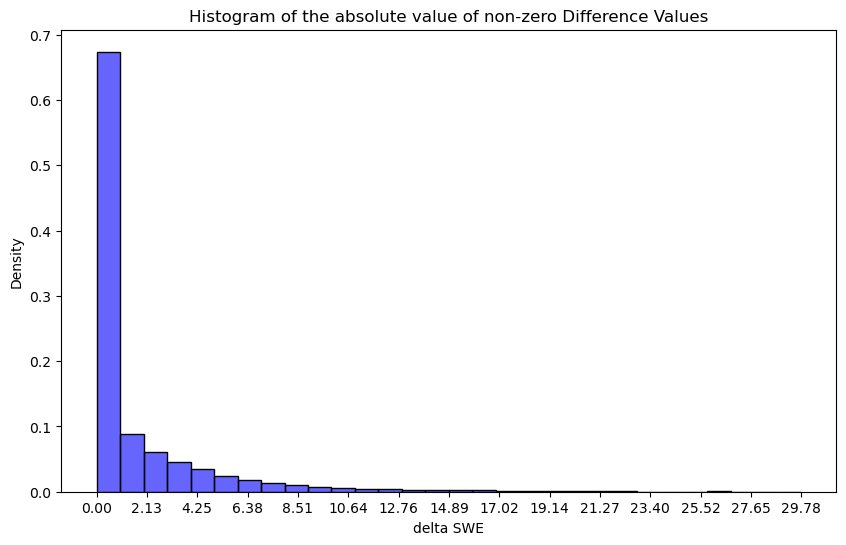

In [90]:
#create histogram and PDF for Without UMRB station assimilation

# Step 4: Flatten the variable_data to 1D array for histogram
flat_data = non_zero_difference_data.flatten()

# Step 5: Plot the histogram and PDF
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(flat_data, bins=30, kde=False, stat='density', color='blue', alpha=0.6)

# Adding labels and title
plt.xlabel('delta SWE')
plt.ylabel('Density')
plt.title('Histogram of the absolute value of non-zero Difference Values')

# Set more tick marks on x-axis
plt.xticks(np.linspace(min(flat_data), max(flat_data), num=15))

# Show the plot
plt.show()

Here are the descriptive statistics for the non zero absolute value of the difference values (Magnitude of difference values)

In [91]:
# Compute basic statistics
data_min = np.min(non_zero_difference_data)
data_max = np.max(non_zero_difference_data)
data_mean = np.mean(non_zero_difference_data)
data_std = np.std(non_zero_difference_data)

# Compute percentiles
percentiles = np.percentile(non_zero_difference_data, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])


Minimum value: 2.1684043449710089e-16
Maximum value: 29.77864633430727
Mean value: 1.6095677714351868
Standard deviation: 3.0703767261313937
25th percentile: 0.003507360816001892
Median (50th percentile): 0.15871250070631504
75th percentile: 1.9024633802473545


## 01/10/24 Assimilation

### Create a Nudging Field using all stations (With UMRB Stations)

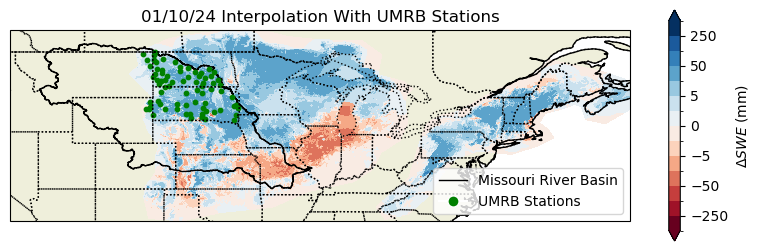

In [25]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_2024011012.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm1054_md_based_2024010912_2024011012_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)',shrink=0.5)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='lower right')

plt.title('01/10/24 Interpolation With UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Creates a Nudging Field Like above but not using UMRB Stations (Without UMRB Stations = new_variable_data)

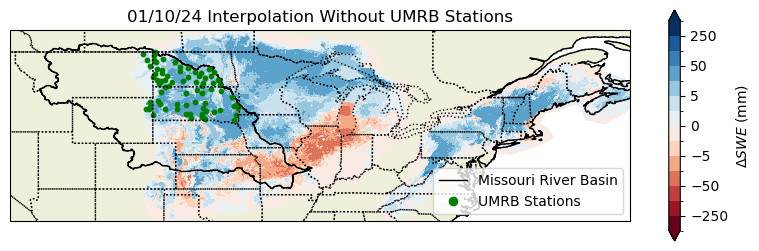

In [26]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_snodas_idw_test_2024011012_central0.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
new_variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm1054_md_based_2024010912_2024011012_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Step 4: Plot the data with a USA base map

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, new_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)', shrink=0.5)

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Overlay the gage stations
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='lower right')

plt.title('01/10/24 Interpolation Without UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

### Create difference data and difference map comparing with and without UMRB

In [27]:
difference_variable_data = (variable_data - new_variable_data)

difference_variable_data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-99999.0)

### Create a Difference Map of With and Without UMRB Stations (difference_variable_data)

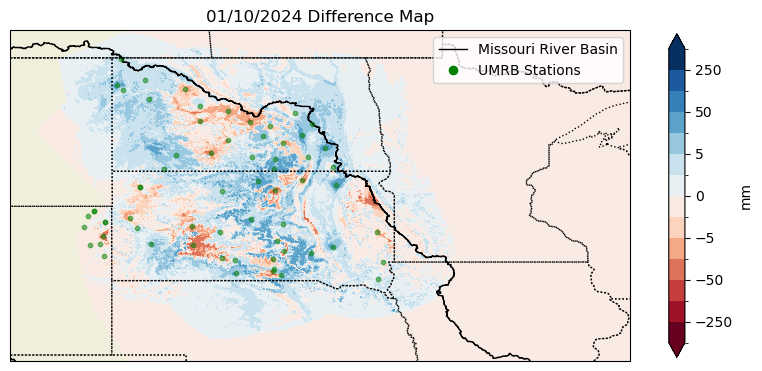

In [75]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_2024011012.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data
contour = ax.contourf(lons, lats, difference_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='mm',shrink=0.7)
plt.title('01/10/2024 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper right')

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed
latitude_padding_2 = (maxx - minx) * 0.3  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding
new_minx = minx + latitude_padding_2
ax.set_extent([new_minx, maxx, new_miny, maxy], crs=ccrs.PlateCarree())

plt.grid(True)
plt.show()

### Create difference map and mask delata SWE values from -1 to 1 for cleaner look and to follow how NOAA employees did it!!!!!!

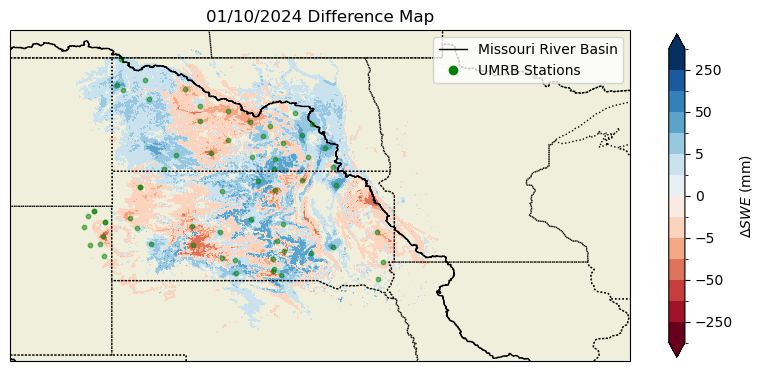

In [29]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_2024011012.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefiles
# Load the gage stations shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Load the boundary layer shapefile
boundary_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\UMRB_boundary_layer.shp"
boundary_gdf = gpd.read_file(boundary_shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# First, mask -9999 values
masked_data = np.ma.masked_where(difference_variable_data == -9999, difference_variable_data)

# Then, mask any values between -1 and 1
masked_data = np.ma.masked_inside(masked_data, -1, 1)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add USA base map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot the contour data with both -9999 and values between -1 and 1 masked
contour = ax.contourf(lons, lats, masked_data, cmap=cmap, norm=norm, levels=bounds, extend='both', transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, label='$\Delta SWE$ (mm)', shrink=0.7)
plt.title('01/10/2024 Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the boundary shapefile
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, transform=ccrs.PlateCarree(), label='Boundary Layer')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10, alpha=0.5, transform=ccrs.PlateCarree())

# Create custom legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1, label='Missouri River Basin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='UMRB Stations')
]

plt.legend(handles=custom_legend, loc='upper right')

# Set the extent to zoom in on the boundary_gdf
minx, miny, maxx, maxy = boundary_gdf.total_bounds
latitude_padding = (maxy - miny) * 0.3  # Adjust padding percentage as needed
latitude_padding_2 = (maxx - minx) * 0.3  # Adjust padding percentage as needed

new_miny = miny + latitude_padding
new_maxy = maxy + latitude_padding
new_minx = minx + latitude_padding_2
ax.set_extent([new_minx, maxx, new_miny, maxy], crs=ccrs.PlateCarree())

plt.grid(True)
plt.show()


### Looking at descriptive statistics of netCDF files (These are basic statistics for the delta SWE values of With UMRB Run (variable_data) and Without UMRB Run (new_variable_data)). Also look at Difference Map Statistics (With - Without UMRB Stations).

These are stats for With UMRB Stations (variable_data) Nudging Layer

In [96]:
# Compute basic statistics for netCDF files 
data_min = np.min(variable_data)
data_max = np.max(variable_data)
data_mean = np.mean(variable_data)
data_std = np.std(variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)


Minimum value: -59.91818755865097
Maximum value: 85.25417745113373
Mean value: 0.6481825850123121
Standard deviation: 6.799856993135512


These are stats for Without UMRB Stations (new_variable_data) Nudging Layer

In [97]:
# Compute basic statistics for netCDF files 
data_min = np.min(new_variable_data)
data_max = np.max(new_variable_data)
data_mean = np.mean(new_variable_data)
data_std = np.std(new_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -59.91818755865097
Maximum value: 85.25417745113373
Mean value: 0.7139749755765846
Standard deviation: 6.834743594783226


These are stats for Difference values (With - Without UMRB Stations) in the Difference Map

In [98]:
# Compute basic statistics for netCDF files 
data_min = np.min(difference_variable_data)
data_max = np.max(difference_variable_data)
data_mean = np.mean(difference_variable_data)
data_std = np.std(difference_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -44.821931049227715
Maximum value: 29.34225555509329
Mean value: -0.06579239056427306
Standard deviation: 1.6211868561790395


Look at difference data without the zero values to see how much values deviate from eachother (This current code is using the absolute value of the difference values exluding zeroes to examine magnitude!!!!)

In [99]:
# Remove all zero values from difference data

# Converting the data to NumPy arrays
difference_variable_data = np.array(difference_variable_data)

# Create array without any zero and -99999 values
non_zero_difference_data = np.abs(difference_variable_data[(difference_variable_data != 0) & (difference_variable_data != -99999)])

Create Histogram of the absolute value of the Difference values

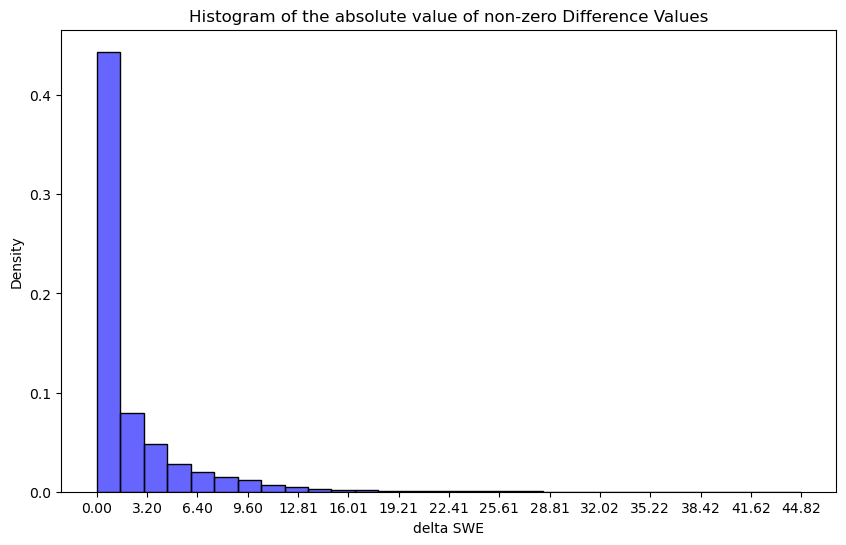

In [100]:
#create histogram and PDF for Without UMRB station assimilation

# Step 4: Flatten the variable_data to 1D array for histogram
flat_data = non_zero_difference_data.flatten()

# Step 5: Plot the histogram and PDF
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(flat_data, bins=30, kde=False, stat='density', color='blue', alpha=0.6)

# Adding labels and title
plt.xlabel('delta SWE')
plt.ylabel('Density')
plt.title('Histogram of the absolute value of non-zero Difference Values')

# Set more tick marks on x-axis
plt.xticks(np.linspace(min(flat_data), max(flat_data), num=15))

# Show the plot
plt.show()

Here are the descriptive statistics for the non zero absolute value of the difference values (Magnitude of difference values)

In [101]:
# Compute basic statistics
data_min = np.min(non_zero_difference_data)
data_max = np.max(non_zero_difference_data)
data_mean = np.mean(non_zero_difference_data)
data_std = np.std(non_zero_difference_data)

# Compute percentiles
percentiles = np.percentile(non_zero_difference_data, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])


Minimum value: 2.7755575615628914e-14
Maximum value: 44.821931049227715
Mean value: 1.9879387248465357
Standard deviation: 3.5077911392685244
25th percentile: 0.012376246530720891
Median (50th percentile): 0.41013542795553803
75th percentile: 2.507437402528012


# Cross Validation for each assimilation

## 12/28/23 Assimilation LOO-CV for IDW, EBK Regression and Universal Kriging

### IDW LOO-CV

In [7]:
# Load the CSV file into a DataFrame
df = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_12_28_23_updated')

# Drop the first column by index (0)
df = df.drop(df.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df['difference'] = df['observed'] - df['analysis']

# Make a list of just UMRB Stations
UMRB_df = df[df['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df = df[~df['site_ids'].isin(UMRB_ID)]

df


,observed,analysis,site_ids,difference
0,20.94453,19.846887,8D3,1.097643
1,21.12781,20.550749,ABES2,0.577061
2,21.12781,20.546585,ABR,0.581225
3,-8.85243,-8.379408,ADAM054,-0.473022
4,15.76905,4.219715,ADAN1,11.549335
...,...,...,...,...
956,-3.20040,-2.258211,WNGN8,-0.942189
957,2.16424,10.157488,WNMS2,-7.993248
958,-10.74352,-3.603530,WRIS2,-7.139990
959,8.79091,8.260490,WTES2,0.530420


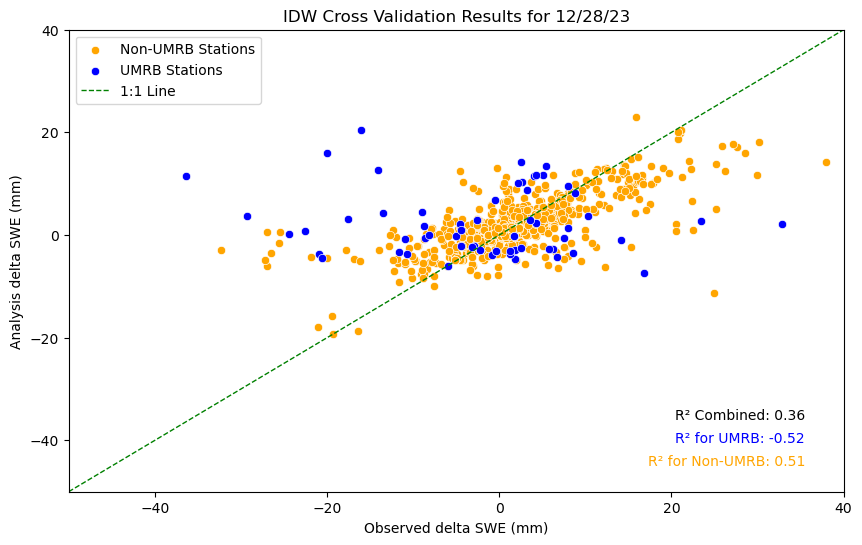

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Sample data
# non_UMRB_df = pd.DataFrame({'observed': [...], 'analysis': [...]})
# UMRB_df = pd.DataFrame({'observed': [...], 'analysis': [...]})

# Combine data for calculating combined R²
combined_observed = pd.concat([non_UMRB_df['observed'], UMRB_df['observed']])
combined_analysis = pd.concat([non_UMRB_df['analysis'], UMRB_df['analysis']])

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Calculate R² values
r2_non_UMRB = r2_score(non_UMRB_df['observed'], non_UMRB_df['analysis'])
r2_UMRB = r2_score(UMRB_df['observed'], UMRB_df['analysis'])
r2_combined = r2_score(combined_observed, combined_analysis)

# Add titles and labels
plt.title('IDW Cross Validation Results for 12/28/23')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-50, 40)
plt.ylim(-50, 40)

# Set ticks in increments of 20 starting from -40
plt.xticks(range(-40, 41, 20))
plt.yticks(range(-40, 41, 20))

# Add 1-to-1 line
plt.plot(range(-50, 41), range(-50, 41), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend(loc='upper left')

# Add a second legend for R² values in the bottom-right corner with color-coding and a box around it
r2_legend = (f'R² for Non-UMRB: {r2_non_UMRB:.2f}\n'
             f'R² for UMRB: {r2_UMRB:.2f}\n'
             f'R² Combined: {r2_combined:.2f}')

# Add individual color formatting
plt.text(0.95, 0.05, f'R² for Non-UMRB: {r2_non_UMRB:.2f}', fontsize=10, color='orange', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.10, f'R² for UMRB: {r2_UMRB:.2f}', fontsize=10, color='blue', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.15, f'R² Combined: {r2_combined:.2f}', fontsize=10, color='black', va='bottom', ha='right', transform=plt.gca().transAxes)

# Display the plot
plt.show()


### EBK Regression LOO-CV

In [17]:
import pandas as pd

# Load the CSV file into a DataFrame
df_2 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\EBK_Regression_LOOCV_updated_12_28_23.csv')

# Drop rows where 'Measured' equals 0
df_2 = df_2[df_2['Measured'] != 0]

# Multiply values in 'Measured' and 'Predicted' columns by -1000
df_2['Measured'] = df_2['Measured'] * -1000
df_2['Predicted'] = df_2['Predicted'] * -1000

# Make a list of just UMRB Stations
UMRB_df = df_2[df_2['STATION_ID'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df = df_2[~df_2['STATION_ID'].isin(UMRB_ID)]

# Calculate the difference between Measured and Predicted values
df_2['difference'] = df_2['Measured'] - df_2['Predicted']

# Keep only the columns 'Measured', 'Predicted', and 'STATION_ID'
df_2 = df_2[['Measured', 'Predicted', 'STATION_ID']]

df_2



,Measured,Predicted,STATION_ID
0,20.94453,20.478154,8D3
1,21.12781,20.374755,ABES2
2,21.12781,20.244100,ABR
3,-8.85243,-8.539140,ADAM054
4,15.76905,2.763970,ADAN1
...,...,...,...
956,-3.20040,-1.805479,WNGN8
957,2.16424,14.630826,WNMS2
958,-10.74352,-7.604429,WRIS2
959,8.79091,6.430229,WTES2


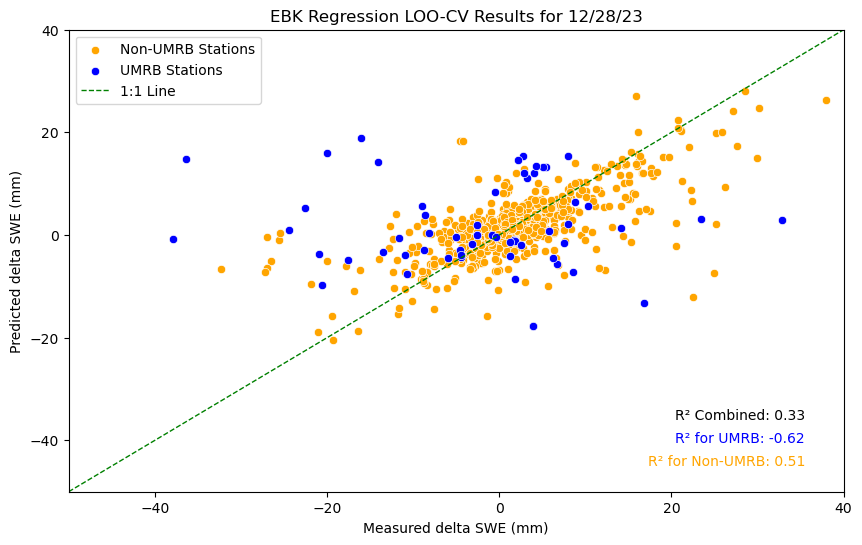

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import pandas as pd

# Combine data for calculating combined R²
combined_Measured = pd.concat([non_UMRB_df['Measured'], UMRB_df['Measured']])
combined_Predicted = pd.concat([non_UMRB_df['Predicted'], UMRB_df['Predicted']])

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df, x='Measured', y='Predicted', color='orange', label='Non-UMRB Stations')

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df, x='Measured', y='Predicted', color='blue', label='UMRB Stations')

# Calculate R² values
r2_non_UMRB = r2_score(non_UMRB_df['Measured'], non_UMRB_df['Predicted'])
r2_UMRB = r2_score(UMRB_df['Measured'], UMRB_df['Predicted'])
r2_combined = r2_score(combined_Measured, combined_Predicted)

# Add titles and labels
plt.title('EBK Regression LOO-CV Results for 12/28/23')
plt.xlabel('Measured delta SWE (mm)')
plt.ylabel('Predicted delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-50, 40)
plt.ylim(-50, 40)

# Set ticks in increments of 20 starting from -40
plt.xticks(range(-40, 41, 20))
plt.yticks(range(-40, 41, 20))

# Add 1-to-1 line
plt.plot(range(-50, 41), range(-50, 41), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend(loc='upper left')

# Add a second legend for R² values in the bottom-right corner with color-coding and a box around it
r2_legend = (f'R² for Non-UMRB: {r2_non_UMRB:.2f}\n'
             f'R² for UMRB: {r2_UMRB:.2f}\n'
             f'R² Combined: {r2_combined:.2f}')

# Add individual color formatting
plt.text(0.95, 0.05, f'R² for Non-UMRB: {r2_non_UMRB:.2f}', fontsize=10, color='orange', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.10, f'R² for UMRB: {r2_UMRB:.2f}', fontsize=10, color='blue', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.15, f'R² Combined: {r2_combined:.2f}', fontsize=10, color='black', va='bottom', ha='right', transform=plt.gca().transAxes)

# Display the plot
plt.show()



### Universal Kriging LOO-CV Results

In [19]:
import pandas as pd

# Load the CSV file into a DataFrame
df_2 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\Universal_Kriging_LOOCV_updated_12_28_23.csv')

# Drop rows where 'Measured' equals 0
df_2 = df_2[df_2['Measured'] != 0]

# Multiply values in 'Measured' and 'Predicted' columns by -1000
df_2['Measured'] = df_2['Measured'] * -1000
df_2['Predicted'] = df_2['Predicted'] * -1000

# Make a list of just UMRB Stations
UMRB_df = df_2[df_2['STATION_ID'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df = df_2[~df_2['STATION_ID'].isin(UMRB_ID)]

# Calculate the difference between Measured and Predicted values
df_2['difference'] = df_2['Measured'] - df_2['Predicted']

# Keep only the columns 'Measured', 'Predicted', and 'STATION_ID'
df_2 = df_2[['Measured', 'Predicted', 'STATION_ID']]

df_2



,Measured,Predicted,STATION_ID
0,20.94453,18.090973,8D3
1,21.12781,20.142169,ABES2
2,21.12781,20.138838,ABR
3,-8.85243,-8.799066,ADAM054
4,15.76905,3.415255,ADAN1
...,...,...,...
956,-3.20040,-1.154457,WNGN8
957,2.16424,6.605328,WNMS2
958,-10.74352,-8.423060,WRIS2
959,8.79091,9.349498,WTES2


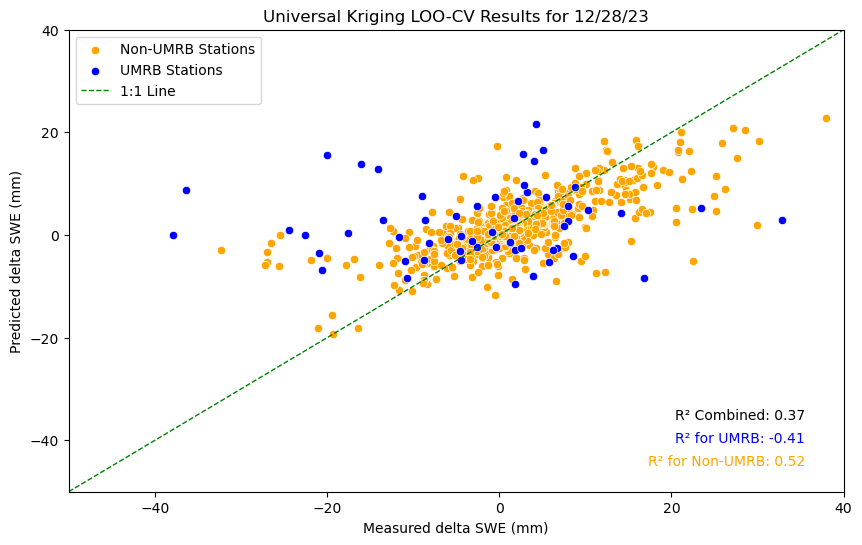

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import pandas as pd

# Combine data for calculating combined R²
combined_Measured = pd.concat([non_UMRB_df['Measured'], UMRB_df['Measured']])
combined_Predicted = pd.concat([non_UMRB_df['Predicted'], UMRB_df['Predicted']])

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df, x='Measured', y='Predicted', color='orange', label='Non-UMRB Stations')

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df, x='Measured', y='Predicted', color='blue', label='UMRB Stations')

# Calculate R² values
r2_non_UMRB = r2_score(non_UMRB_df['Measured'], non_UMRB_df['Predicted'])
r2_UMRB = r2_score(UMRB_df['Measured'], UMRB_df['Predicted'])
r2_combined = r2_score(combined_Measured, combined_Predicted)

# Add titles and labels
plt.title('Universal Kriging LOO-CV Results for 12/28/23')
plt.xlabel('Measured delta SWE (mm)')
plt.ylabel('Predicted delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-50, 40)
plt.ylim(-50, 40)

# Set ticks in increments of 20 starting from -40
plt.xticks(range(-40, 41, 20))
plt.yticks(range(-40, 41, 20))

# Add 1-to-1 line
plt.plot(range(-50, 41), range(-50, 41), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend(loc='upper left')

# Add a second legend for R² values in the bottom-right corner with color-coding and a box around it
r2_legend = (f'R² for Non-UMRB: {r2_non_UMRB:.2f}\n'
             f'R² for UMRB: {r2_UMRB:.2f}\n'
             f'R² Combined: {r2_combined:.2f}')

# Add individual color formatting
plt.text(0.95, 0.05, f'R² for Non-UMRB: {r2_non_UMRB:.2f}', fontsize=10, color='orange', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.10, f'R² for UMRB: {r2_UMRB:.2f}', fontsize=10, color='blue', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.15, f'R² Combined: {r2_combined:.2f}', fontsize=10, color='black', va='bottom', ha='right', transform=plt.gca().transAxes)

# Display the plot
plt.show()

## 01/10/24 Assimilation LOO-CV for IDW

In [10]:
# Load the CSV file into a DataFrame
df_2 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_01_10_24')

# Drop the first column by index (0)
df_2 = df_2.drop(df_2.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df_2['difference'] = df_2['observed'] - df_2['analysis']

# Make a list of just UMRB Stations
UMRB_df_2 = df_2[df_2['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df_2 = df_2[~df_2['site_ids'].isin(UMRB_ID)]

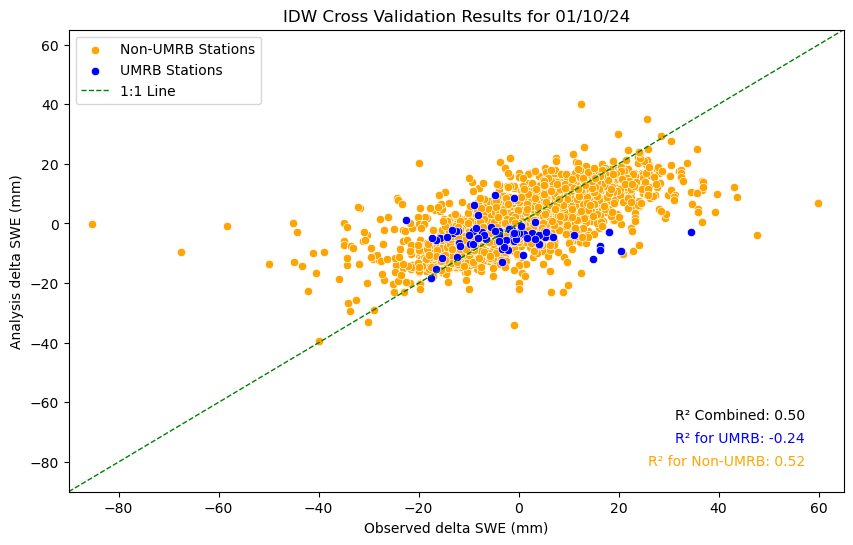

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Combine data for calculating combined R²
combined_observed = pd.concat([non_UMRB_df_2['observed'], UMRB_df_2['observed']])
combined_analysis = pd.concat([non_UMRB_df_2['analysis'], UMRB_df_2['analysis']])

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df_2, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df_2, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Calculate R² values
r2_non_UMRB = r2_score(non_UMRB_df_2['observed'], non_UMRB_df_2['analysis'])
r2_UMRB = r2_score(UMRB_df_2['observed'], UMRB_df_2['analysis'])
r2_combined = r2_score(combined_observed, combined_analysis)

# Add titles and labels
plt.title('IDW Cross Validation Results for 01/10/24')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-90, 65)
plt.ylim(-90, 65)

# Set ticks in increments of 20 starting from -80
plt.xticks(range(-80, 66, 20))
plt.yticks(range(-80, 66, 20))

# Add 1-to-1 line
plt.plot(range(-90, 66), range(-90, 66), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend(loc='upper left')

# Add a second legend for R² values in the bottom-right corner with color-coding and a box around it
r2_legend = (f'R² for Non-UMRB: {r2_non_UMRB:.2f}\n'
             f'R² for UMRB: {r2_UMRB:.2f}\n'
             f'R² Combined: {r2_combined:.2f}')

# Add individual color formatting
plt.text(0.95, 0.05, f'R² for Non-UMRB: {r2_non_UMRB:.2f}', fontsize=10, color='orange', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.10, f'R² for UMRB: {r2_UMRB:.2f}', fontsize=10, color='blue', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.15, f'R² Combined: {r2_combined:.2f}', fontsize=10, color='black', va='bottom', ha='right', transform=plt.gca().transAxes)

# Display the plot
plt.show()


## 12/11/22 Assimilation LOO-CV for IDW

In [13]:
# Load the CSV file into a DataFrame
df_3 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_12_11_22')

# Drop the first column by index (0)
df_3 = df_3.drop(df_3.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df_3['difference'] = df_3['observed'] - df_3['analysis']

# Make a list of just UMRB Stations
UMRB_df_3 = df_3[df_3['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df_3 = df_3[~df_3['site_ids'].isin(UMRB_ID)]

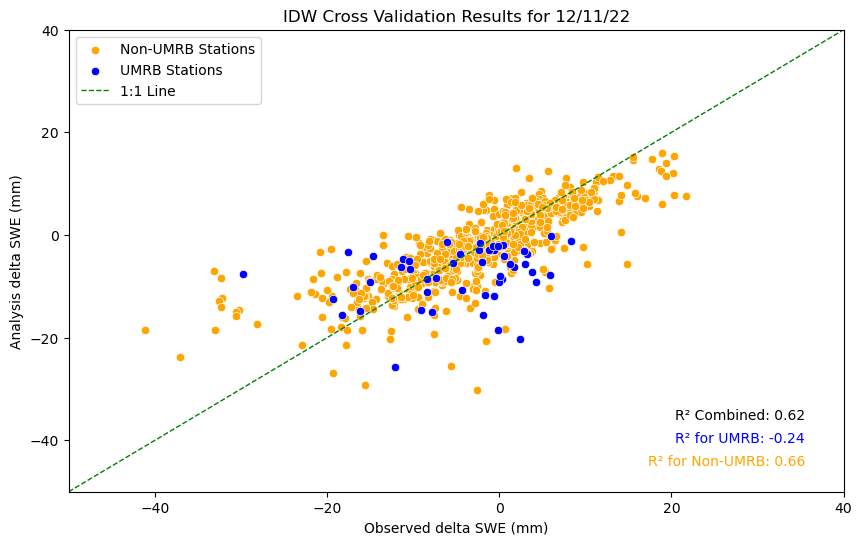

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Combine data for calculating combined R²
combined_observed = pd.concat([non_UMRB_df_3['observed'], UMRB_df_3['observed']])
combined_analysis = pd.concat([non_UMRB_df_3['analysis'], UMRB_df_3['analysis']])

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df_3, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df_3, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Calculate R² values
r2_non_UMRB = r2_score(non_UMRB_df_3['observed'], non_UMRB_df_3['analysis'])
r2_UMRB = r2_score(UMRB_df_3['observed'], UMRB_df_3['analysis'])
r2_combined = r2_score(combined_observed, combined_analysis)

# Add titles and labels
plt.title('IDW Cross Validation Results for 12/11/22')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-50, 40)
plt.ylim(-50, 40)

# Set ticks in increments of 20 starting from -40
plt.xticks(range(-40, 41, 20))
plt.yticks(range(-40, 41, 20))

# Add 1-to-1 line
plt.plot(range(-50, 41), range(-50, 41), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend(loc='upper left')

# Add a second legend for R² values in the bottom-right corner with color-coding and a box around it
r2_legend = (f'R² for Non-UMRB: {r2_non_UMRB:.2f}\n'
             f'R² for UMRB: {r2_UMRB:.2f}\n'
             f'R² Combined: {r2_combined:.2f}')

# Add individual color formatting
plt.text(0.95, 0.05, f'R² for Non-UMRB: {r2_non_UMRB:.2f}', fontsize=10, color='orange', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.10, f'R² for UMRB: {r2_UMRB:.2f}', fontsize=10, color='blue', va='bottom', ha='right', transform=plt.gca().transAxes)
plt.text(0.95, 0.15, f'R² Combined: {r2_combined:.2f}', fontsize=10, color='black', va='bottom', ha='right', transform=plt.gca().transAxes)

# Display the plot
plt.show()


## Analysis of LOO-CV Methods and Overall Anaylsis of UMRB Station Performance

### Different interpolation methods were used for the assimilation date of 12/28/23 to see if the method used was the possible reason for poor prediction at the UMRB stations. When comparing an EBK Regression and Unviversal kriging interpolation method to the IDW method currently used in the creation of the nudging layers we see very little difference in performance with IDW (R^2 = 0.36) outperforming EBK regression (R^2 = 0.33) and on par with Universal Kriging (R^2 = 0.37). The equally poor performance from each of the three interpolation methods in accuratley predicting delta SWE at the UMRB Stations is a further indication of the benefit these stations have in improving the performance of the SNODAS model.

### When analyzing the cross-validation results for these assimilations, the IDW interpolation method performs poorly in predicting delta SWE at certain UMRB stations. This is especially evident in the 12/28/23 event, where we observe poor accuracy at many UMRB stations, underscoring their critical role in accurately predicting SWE in the UMRB region. Although there are much fewer URMB stations than others, the negative coefficient of determination (R²) values for in the figures show that the model is not able to predict SWE as well at these stations. However, further research is needed to better understand if these results are indicative of UMRB data representativeness, or if adjustments to IDW interpolation method are needed. The methodology recognizes potential shortcomings of the IDW interpolation method in capturing the spatial variability of delta SWE. Future research will explore alternative interpolation techniques and compare their accuracy in representing the spatial variance of delta SWE within the UMRB region.
